<a href="https://colab.research.google.com/github/pachterlab/varseek-examples/blob/main/vk_denovo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# [vk denovo](https://github.com/pachterlab/varseek) demonstration
Call de novo variants from scRNA-seq reads, build a varseek reference from those variants, and count variant-supporting reads with vk count. This notebook uses a [10x PBMC 1k dataset](https://www.10xgenomics.com/datasets/1-k-pbm-cs-from-a-healthy-donor-v-3-chemistry-3-standard-3-0-0) as an example.

Written by Joseph Rich.
___


### Install varseek, and import all packages

In [1]:
try:
    import varseek as vk
except ImportError:
    print("varseek not found, installing...")
    !pip install -U -q varseek

In [2]:
import os
import re
import anndata as ad
import pandas as pd
import pysam

import varseek as vk

### Define important paths

In [ ]:
# input files
fastqs_dir = os.path.join("data", "pbmc_1k_v3_fastqs")
technology = "10xv3"
reference_dir = os.path.join("data", "reference")
sequences = os.path.join(reference_dir, "Homo_sapiens.GRCh38.dna.primary_assembly.fa")
gtf = os.path.join(reference_dir, "Homo_sapiens.GRCh38.114.gtf")

# vk denovo out
variants_dir = os.path.join("data", "pbmc_1k_v3_variants")
variants_vcf = os.path.join(variants_dir, "variants.vcf.gz")
variants = os.path.join(variants_dir, "variants.tsv")
denovo_bam_dir = os.path.join(variants_dir, "bams")
star_genome_index_dir = os.path.join(reference_dir, "star_index")
denovo_star_alignment_dir = os.path.join(variants_dir, "star_alignments")

# vk ref out
vk_ref_out_dir = os.path.join("data", "varseek_ref_out_pbmc_1k_v3")
vcrs_index = os.path.join(vk_ref_out_dir, "vcrs_index_denovo.idx")
vcrs_t2g = os.path.join(vk_ref_out_dir, "vcrs_t2g_denovo.txt")

# vk count out
vk_count_out_dir = os.path.join("data", "varseek_count_out_pbmc_1k_v3")
vk_count_variants_vcf = os.path.join(vk_count_out_dir, "varseek_variants.vcf")

# general parameters
w = 37
k = 41
min_counts_denovo = 3
threads = 16
use_unfiltered_varseek = True

### Download the PBMC fastq dataset

In [4]:
if not os.path.exists(fastqs_dir) or len(os.listdir(fastqs_dir)) == 0:
    !mkdir -p data && \
        cd data && \
        curl -O https://cf.10xgenomics.com/samples/cell-exp/3.0.0/pbmc_1k_v3/pbmc_1k_v3_fastqs.tar && \
        tar -xvf pbmc_1k_v3_fastqs.tar && \
        rm pbmc_1k_v3_fastqs.tar

### Download the reference genome (GRCh38, Ensembl 114, cDNA file)

In [5]:
if not os.path.exists(sequences):
    !gget ref -w dna -r 114 --out_dir {reference_dir} -d human
    !gunzip {sequences}.gz

if not os.path.exists(gtf):
    !gget ref -w gtf -r 114 --out_dir {reference_dir} -d human
    !gunzip {gtf}.gz

### Run varseek denovo

In [6]:
fastq_r2_files = sorted(
    os.path.join(root, file)
    for root, _, files in os.walk(fastqs_dir)
    for file in files
    if file.endswith((".fastq.gz", ".fq.gz", ".fastq", ".fq")) and "_R2_" in file
)

if not os.path.exists(variants):
    vk.denovo(
        inputs=fastq_r2_files,
        fasta_ref=sequences,
        gtf=gtf,
        aligner="STAR",
        star_genome_index_dir=star_genome_index_dir,
        star_alignment_prefix=f"{denovo_star_alignment_dir}/star_",
        out_bam_dir=denovo_bam_dir,
        output=variants_vcf,
        output_tsv=variants,
        min_counts=min_counts_denovo,
        threads=threads,
        read_length=91,
        verbose=1,
    )


variants_df = pd.read_csv(variants, sep="\t")
print(f"Number of variants: {len(variants_df)}")
variants_df.head()

Number of variants: 325576


/home/jrich/tmp/ipykernel_486782/3070598833.py:26: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  variants_df = pd.read_csv(variants, sep="\t")


,seq_id,variant
0,1,g.199391G>A
1,1,g.511638T>C
2,1,g.511644T>C
3,1,g.511685T>C
4,1,g.511693T>C


### Run varseek ref

In [7]:
if not os.path.exists(vcrs_index):
    vk_ref_output_dict = vk.ref(
        variants=variants,
        sequences=sequences,
        seq_id_column="seq_id",
        var_column="variant",
        out=vk_ref_out_dir,
        reference_out_dir=reference_dir,
        dlist_reference_source="t2t",
        index_out=vcrs_index,
        t2g_out=vcrs_t2g,
        w=w,
        k=k
    )

### Run varseek count

This will run the following commands:
- `varseek fastqpp`: Preprocess the fastq files. By default, does nothing.
- `kb count` (variant reference): Perform variant screening on fastq data utilizing kb count's pseudoalignment algorithm. Variant data is stored in an Anndata object as as cell/sample x variant matrix.
- `kb count` ("normal" reference genome) (optional): Perform pseudoalignment of fastq data to the reference genome. Only performed if utilized in the subsequence "varseek clean" step. By default, will occur if the path to the necessary files are not provided as input.
- `varseek clean`: Process the output of kb count. By default, this will threshold variant counts and ensure that there is agreement for each read between the gene of the variant to which the read aligned during the variant reference pseudoalignment and the gene to which the read aligned during the "normal" reference genome pseudoalignment.
- `varseek summarize`: Produces a text file summarizing some high-level insights from the variant screening process.

In [8]:
vk_count_output_dict = vk.count(
    fastqs_dir,
    index=vcrs_index,
    t2g=vcrs_t2g,
    technology=technology,
    out=vk_count_out_dir,
    k=k,
    threads=threads,
    save_vcf=True
)

10:25:51 - INFO - Error sorting fastq files: File data/pbmc_1k_v3_fastqs/combined_R2.fastq.gz does not match the expected bulk file naming convention of SAMPLE_PAIR.EXT where SAMPLE is sample name, PAIR is 1/2, and EXT is a fastq extension - or the Illumina file naming convention of SAMPLE_LANE_R[12]_001.fastq.gz, where SAMPLE is letters, numbers, underscores; LANE is numbers with optional leading 0s; pair is either R1 or R2; and it has .fq or .fastq extension (or .fq.gz or .fastq.gz).
Raising exception and exiting because sort_fastqs=True, which requires standard bulk or Illumina file naming convention. Please check fastq file names or set sort_fastqs=False.. Returning unsorted fastq files
10:25:51 - INFO - Setting length_required to 41 if fastqpp is run
10:25:51 - INFO - Skipping vk fastqpp because there was no use for it
10:25:51 - INFO - Skipping kb count because file data/varseek_count_out_pbmc_1k_v3/kb_count_out_vcrs/counts_unfiltered/adata.h5ad already exists and overwrite=False

In [ ]:
# adata = ad.read_h5ad(vk_count_output_dict["adata_path_unprocessed"])
# adata.var.head()

""
gene_id
1:g.199391G>A
1:g.511638T>C
1:g.511644T>C
1:g.511685T>C
1:g.511693T>C


In [9]:
print(f"Find the processed adata object for further analysis in {vk_count_output_dict['adata_path']}")

Find the processed adata object for further analysis in /home/jrich/Desktop/varseek-examples/data/varseek_count_out_pbmc_1k_v3/adata_cleaned.h5ad


In [ ]:
from tqdm import tqdm

varseek_vcf = os.path.join(vk_count_out_dir, "varseek_variants.vcf")
if not os.path.exists(varseek_vcf):
    adata_path = vk_count_output_dict['adata_path'] if not use_unfiltered_varseek else vk_count_output_dict['adata_path_unprocessed']
    adata = ad.read_h5ad(adata_path)
    adata = adata[:, adata.X.sum(axis=0) > 0]  # filter to only keep variants present in at least 1 cell
    variants = adata.var_names.tolist()

    # Reference genome FASTA
    fasta = pysam.FastaFile(sequences)

    vcf_rows = []

    chromosomes = {str(i) for i in range(1, 23)}.union({"X", "Y", "MT"})
    for grouped_vars in tqdm(variants, desc="Processing variants"):
        # split var by ";"
        for var in grouped_vars.split(";"):
            # SNV
            m = re.match(r"(.+):g\.(\d+)([ACGT]+)>([ACGT]+)", var)
            if m:
                chrom, pos, ref, alt = m.groups()
                if chrom not in chromosomes:
                    continue

                vcf_rows.append({
                    "CHROM": chrom,
                    "POS": int(pos),
                    "ID": ".",
                    "REF": ref,
                    "ALT": alt,
                    "QUAL": ".",
                    "FILTER": ".",
                    "INFO": "."
                })

                continue

            # insertion
            m = re.match(r"(.+):g\.(\d+)_(\d+)ins([ACGT]+)", var)
            if m:
                chrom, pos, end, inserted = m.groups()
                if chrom not in chromosomes:
                    continue

                pos = int(pos)

                # VCF requires left anchor base
                anchor = fasta.fetch(chrom, pos - 1, pos)

                ref = anchor
                alt = anchor + inserted

                vcf_rows.append({
                    "CHROM": chrom,
                    "POS": pos,
                    "ID": ".",
                    "REF": ref,
                    "ALT": alt,
                    "QUAL": ".",
                    "FILTER": ".",
                    "INFO": "."
                })

                continue
                
            # deletion (single-base or interval)
            m = re.match(r"(.+):g\.(\d+)(?:_(\d+))?del([ACGT]*)", var)
            if m:
                chrom, start, end, deleted = m.groups()

                if chrom not in chromosomes:
                    continue

                start = int(start)
                end = int(end) if end is not None else start

                # VCF requires left anchor base
                anchor = fasta.fetch(chrom, start - 2, start - 1)

                # if deleted sequence not specified in HGVS,
                # fetch it from reference genome
                if deleted == "":
                    deleted = fasta.fetch(chrom, start - 1, end)

                ref = anchor + deleted
                alt = anchor

                vcf_rows.append({
                    "CHROM": chrom,
                    "POS": start - 1,
                    "ID": ".",
                    "REF": ref,
                    "ALT": alt,
                    "QUAL": ".",
                    "FILTER": ".",
                    "INFO": "."
                })

                continue

            print(f"Could not parse: {var}")

        # Convert to dataframe
        vcf_df = pd.DataFrame(vcf_rows)

        # Write VCF
        with open(varseek_vcf, "w") as f:

            f.write("##fileformat=VCFv4.2\n")
            f.write("#CHROM\tPOS\tID\tREF\tALT\tQUAL\tFILTER\tINFO\n")

            for _, row in vcf_df.iterrows():
                f.write(
                    f"{row.CHROM}\t"
                    f"{row.POS}\t"
                    f"{row.ID}\t"
                    f"{row.REF}\t"
                    f"{row.ALT}\t"
                    f"{row.QUAL}\t"
                    f"{row.FILTER}\t"
                    f"{row.INFO}\n"
                )

Processing variants:   2%|▏         | 386/19190 [03:39<2:58:29,  1.76it/s]  


KeyboardInterrupt: 

In [11]:
fastq_r2_file_combined = os.path.join(fastqs_dir, "combined_R2.fastq.gz")
if not os.path.exists(fastq_r2_file_combined):
    r2_files = sorted(
        os.path.join(root, file)
        for root, _, files in os.walk(fastqs_dir)
        for file in files
        if file.endswith((".fastq.gz", ".fq.gz", ".fastq", ".fq")) and "_R2_" in file
    )
    with open(fastq_r2_file_combined, "wb") as wfd:
        for r2_file in r2_files:
            with open(r2_file, "rb") as fd:
                wfd.write(fd.read())

In [12]:
genomes1000_vcf = os.path.join(reference_dir, "1000GENOMES-phase_3.vcf")
picard_jar = "/home/jrich/opt/picard.jar"
gatk_out = os.path.join("data", "gatk_out")
tmp_dir = os.path.join("data", "tmp")

if not os.path.exists(tmp_dir):
    os.makedirs(tmp_dir)

if not os.path.exists(genomes1000_vcf):
    !wget -O {genomes1000_vcf}.gz "https://ftp.ensembl.org/pub/release-114/variation/vcf/homo_sapiens/1000GENOMES-phase_3.vcf.gz"
    !gunzip {genomes1000_vcf}.gz

In [13]:
model_dir = os.path.join("data", "deepvariant_model")
deepvariant_vcf = os.path.join(gatk_out, "vcf_output", "deepvariant_variants.vcf.gz")

if not os.path.exists(deepvariant_vcf):
    !echo python /home/jrich/Desktop/RLSRP_2025/scripts/run_deepvariant_for_benchmarking.py \
        --synthetic_read_fastq {fastq_r2_file_combined} \
        --reference_genome_fasta {sequences} \
        --reference_genome_gtf {gtf} \
        --star_genome_dir {star_genome_index_dir} \
        --read_length 91 \
        --model_dir {model_dir} \
        --docker podman \
        --out {gatk_out} \
        --skip_accuracy_analysis

In [14]:
haplotypecaller_vcf = os.path.join(gatk_out, "vcfs", "haplotypecaller", "haplotypecaller_output_filtered_applied.vcf.gz")

if not os.path.exists(haplotypecaller_vcf):
    !echo python /home/jrich/Desktop/RLSRP_2025/scripts/run_gatk_haplotypecaller_for_benchmarking.py \
        --synthetic_read_fastq {fastq_r2_file_combined} \
        --reference_genome_fasta {sequences} \
        --reference_genome_gtf {gtf} \
        --genomes1000_vcf {genomes1000_vcf} \
        --star_genome_dir {star_genome_index_dir} \
        --read_length 91 \
        --picard_jar {picard_jar} \
        --threads {threads} \
        --tmp_dir {tmp_dir} \
        --out {gatk_out} \
        --skip_accuracy_analysis

In [15]:
mutect2_vcf = os.path.join(gatk_out, "vcfs", "mutect2", "mutect2_output_filtered_applied.vcf.gz")

# PYTHONBREAKPOINT=0 disables the stray breakpoint() in the script for non-interactive runs.
# --java points GATK/Picard at JDK 17.
if not os.path.exists(mutect2_vcf):
    !PYTHONBREAKPOINT=0 python /home/jrich/Desktop/RLSRP_2025/scripts/run_gatk_mutect2_for_benchmarking.py \
        --synthetic_read_fastq {fastq_r2_file_combined} \
        --reference_genome_fasta {sequences} \
        --reference_genome_gtf {gtf} \
        --genomes1000_vcf {genomes1000_vcf} \
        --star_genome_dir {star_genome_index_dir} \
        --read_length 91 \
        --picard_jar {picard_jar} \
        --java "/home/jrich/opt/jdk-17.0.12+7/bin/java" \
        --threads {threads} \
        --tmp_dir {tmp_dir} \
        --out {gatk_out} \
        --skip_accuracy_analysis

In [16]:
import os
import gzip
import subprocess

def is_vcf_normalized(vcf_path):
    """
    Returns True if the VCF has a header line indicating bcftools norm was run.
    """
    # Auto-detect if compressed
    open_func = gzip.open if vcf_path.endswith(".gz") else open

    with open_func(vcf_path, "rt") as f:
        for line in f:
            if line.startswith("##bcftools_normCommand="):
                return True
            # Headers always start with ##
            if not line.startswith("##"):
                # Stop at the column header line
                break
    return False

def ensure_genotype_column(vcf_path, sample_name="SAMPLE", genotype="1/1"):
    """hap.py requires at least one sample carrying genotypes. varseek emits a
    sites-only VCF (CHROM..INFO only), so inject a placeholder FORMAT/GT column
    if none is present. No-op for VCFs that already have sample columns."""
    open_func = gzip.open if vcf_path.endswith(".gz") else open

    with open_func(vcf_path, "rt") as f:
        lines = f.readlines()

    for line in lines:
        if line.startswith("#CHROM"):
            if len(line.rstrip("\n").split("\t")) > 8:
                return  # FORMAT + sample columns already present
            break

    gt_header = '##FORMAT=<ID=GT,Number=1,Type=String,Description="Genotype">\n'
    new_lines = []
    inserted_header = False
    for line in lines:
        if line.startswith("##"):
            new_lines.append(line)
        elif line.startswith("#CHROM"):
            if not inserted_header:
                new_lines.append(gt_header)
                inserted_header = True
            cols = line.rstrip("\n").split("\t") + ["FORMAT", sample_name]
            new_lines.append("\t".join(cols) + "\n")
        elif line.strip():
            cols = line.rstrip("\n").split("\t") + ["GT", genotype]
            new_lines.append("\t".join(cols) + "\n")

    with open(vcf_path, "wt") as f:
        f.writelines(new_lines)

def insert_suffix_before_first_dot(path, suffix):
    dirname, basename = os.path.split(path)
    if "." in basename:
        parts = basename.split(".", 1)
        new_basename = parts[0] + suffix + "." + parts[1]
    else:
        new_basename = basename + suffix
    return os.path.join(dirname, new_basename)

def add_normalized_before_first_dot(path):
    return insert_suffix_before_first_dot(path, "_normalized")

def filter_to_variant_calls(vcf_path):
    """Keep only records where the sample actually carries an ALT allele, dropping
    hom-ref (0/0) and no-call (./.) records -- e.g. DeepVariant 'RefCall' sites,
    which make up the bulk of its output. Left in, these non-variant records
    dominate the hap.py query totals and collapse precision. The FILTER column is
    preserved so hap.py can still stratify ALL vs PASS."""
    out_path = insert_suffix_before_first_dot(vcf_path, "_nonref")

    if os.path.isfile(out_path) and os.path.getsize(out_path) > 0:
        print(f"Filtered file {out_path} already exists. Skipping filtering.")
    else:
        output_type = "-Oz" if out_path.endswith(".vcf.gz") else "-Ov"
        subprocess.run(
            ["bcftools", "view", "-i", 'GT="alt"', output_type, "-o", out_path, vcf_path],
            check=True,
        )
    return out_path

def make_normalized_vcf(test_vcf, reference_fasta):
    test_vcf_unnormalized = test_vcf
    test_vcf = add_normalized_before_first_dot(test_vcf_unnormalized)

    # Treat a zero-byte file as missing: a previous bcftools failure can leave an
    # empty output behind, and a plain isfile() check would silently reuse it.
    if os.path.isfile(test_vcf) and os.path.getsize(test_vcf) > 0:
        print(f"Normalized file {test_vcf} already exists. Skipping normalization.")
    else:
        reference_fasta_index = f"{reference_fasta}.fai"
        if not os.path.isfile(reference_fasta_index):
            subprocess.run(["samtools", "faidx", reference_fasta], check=True)

        output_type = "-Oz" if test_vcf.endswith(".vcf.gz") else "-Ov"
        # Pipeline: reheader -> norm -> sort.
        #  * reheader --fai: the varseek VCF carries no ##contig header lines, which
        #    makes `bcftools norm` abort with "CONTIG id not present in the header"
        #    and leaves an empty file. Add/refresh contig lines from the reference.
        #  * norm: left-align, split multiallelics, check against the reference.
        #  * sort: the varseek records are not grouped by chromosome, so tabix
        #    indexing later fails with "chromosome blocks not continuous".
        reheader_proc = subprocess.Popen(
            ["bcftools", "reheader", "--fai", reference_fasta_index, test_vcf_unnormalized],
            stdout=subprocess.PIPE,
        )
        norm_proc = subprocess.Popen(
            ["bcftools", "norm", "-c", "w", "-f", reference_fasta, "-m", "-both", "-Ou"],
            stdin=reheader_proc.stdout, stdout=subprocess.PIPE,
        )
        reheader_proc.stdout.close()
        subprocess.run(["bcftools", "sort", output_type, "-o", test_vcf], stdin=norm_proc.stdout, check=True)
        norm_proc.stdout.close()
        if reheader_proc.wait() != 0:
            raise subprocess.CalledProcessError(reheader_proc.returncode, "bcftools reheader")
        if norm_proc.wait() != 0:
            raise subprocess.CalledProcessError(norm_proc.returncode, "bcftools norm")

    # sites-only VCFs (e.g. varseek) need a placeholder genotype for hap.py
    ensure_genotype_column(test_vcf)

    if test_vcf.endswith(".gz") and not os.path.isfile(f"{test_vcf}.tbi"):
        subprocess.run(["bcftools", "index", "-f", "-t", test_vcf], check=True)

    return test_vcf

def compare_with_happy(varseek_vcf, alternate_vcf, reference_fasta, output_dir, output_prefix="happy"):
    varseek_vcf = os.path.abspath(varseek_vcf)
    alternate_vcf = os.path.abspath(alternate_vcf)
    reference_fasta = os.path.abspath(reference_fasta)
    output_dir = os.path.abspath(output_dir)
    
    varseek_vcf_dir = os.path.dirname(varseek_vcf)
    alternate_vcf_dir = os.path.dirname(alternate_vcf)
    reference_fasta_dir = os.path.dirname(reference_fasta)

    reference_fasta_index = f"{reference_fasta}.fai"
    if not os.path.isfile(reference_fasta_index):
        subprocess.run(["samtools", "faidx", reference_fasta], check=True)

    # Drop non-variant (hom-ref / no-call) records from the caller VCF before
    # comparison; varseek emits only variant sites so it needs no such filter.
    alternate_vcf = filter_to_variant_calls(alternate_vcf)

    if not is_vcf_normalized(alternate_vcf):
        alternate_vcf = make_normalized_vcf(alternate_vcf, reference_fasta)

    if not is_vcf_normalized(varseek_vcf):
        varseek_vcf = make_normalized_vcf(varseek_vcf, reference_fasta)

    summary_csv_path = os.path.join(output_dir, f"{output_prefix}.summary.csv")

    if os.path.isfile(summary_csv_path):
        print(f"Summary file {summary_csv_path} already exists. Skipping hap.py run.")
    else:
        os.makedirs(output_dir, exist_ok=True)
        output_prefix_full = os.path.join(output_dir, output_prefix)
        command = f"podman run --rm -v {varseek_vcf_dir}:{varseek_vcf_dir} -v {alternate_vcf_dir}:{alternate_vcf_dir} -v {reference_fasta_dir}:{reference_fasta_dir} -v {output_dir}:{output_dir} mgibio/hap.py:v0.3.12 /opt/hap.py/bin/hap.py -r {reference_fasta} --engine=scmp-somatic -o {output_prefix_full} {varseek_vcf} {alternate_vcf}"
        subprocess.run(command, shell=True, check=True)


In [17]:
happy_out = os.path.join("data", "happy_output")

for label, alternate_vcf in [("deepvariant", deepvariant_vcf), ("haplotypecaller", haplotypecaller_vcf), ("mutect2", mutect2_vcf)]:
    if not os.path.exists(alternate_vcf):
        print(f"Alternate VCF {alternate_vcf} does not exist. Skipping comparison for {label}.")
        continue
    compare_with_happy(
        varseek_vcf=vk_count_variants_vcf,
        alternate_vcf=alternate_vcf,
        reference_fasta=sequences,
        output_dir=happy_out,
        output_prefix=f"varseek_vs_{label}"
    )

Filtered file /home/jrich/Desktop/varseek-examples/data/gatk_out/vcf_output/deepvariant_variants_nonref.vcf.gz already exists. Skipping filtering.
Normalized file /home/jrich/Desktop/varseek-examples/data/gatk_out/vcf_output/deepvariant_variants_nonref_normalized.vcf.gz already exists. Skipping normalization.
Normalized file /home/jrich/Desktop/varseek-examples/data/varseek_count_out_pbmc_1k_v3/varseek_variants_normalized.vcf already exists. Skipping normalization.
Summary file /home/jrich/Desktop/varseek-examples/data/happy_output/varseek_vs_deepvariant.summary.csv already exists. Skipping hap.py run.
Filtered file /home/jrich/Desktop/varseek-examples/data/gatk_out/vcfs/haplotypecaller/haplotypecaller_output_filtered_applied_nonref.vcf.gz already exists. Skipping filtering.
Normalized file /home/jrich/Desktop/varseek-examples/data/gatk_out/vcfs/haplotypecaller/haplotypecaller_output_filtered_applied_nonref_normalized.vcf.gz already exists. Skipping normalization.
Normalized file /home

In [18]:
# Collect the hap.py summary tables into one view.
# varseek is the TRUTH set and each caller is the QUERY, so:
#   Recall    = fraction of varseek calls confirmed by the caller
#   Precision = fraction of the caller's calls also in varseek (low by design:
#               varseek reports a small targeted subset vs. a genome-wide caller)
summary_frames = []
for label, alternate_vcf in [("deepvariant", deepvariant_vcf), ("haplotypecaller", haplotypecaller_vcf), ("mutect2", mutect2_vcf)]:
    summary_csv_path = os.path.join(happy_out, f"varseek_vs_{label}.summary.csv")
    if not os.path.isfile(summary_csv_path):
        continue
    df = pd.read_csv(summary_csv_path)
    df.insert(0, "Caller", label)
    summary_frames.append(df)

if summary_frames:
    summary_all = pd.concat(summary_frames, ignore_index=True)
    cols = ["Caller", "Type", "Filter", "TRUTH.TOTAL", "TRUTH.TP", "TRUTH.FN",
            "QUERY.TOTAL", "QUERY.FP", "METRIC.Recall", "METRIC.Precision", "METRIC.F1_Score"]
    display(summary_all[cols])
else:
    print("No hap.py summaries found yet -- run the comparison cell above first.")


,Caller,Type,Filter,TRUTH.TOTAL,TRUTH.TP,TRUTH.FN,QUERY.TOTAL,QUERY.FP,METRIC.Recall,METRIC.Precision,METRIC.F1_Score
0,deepvariant,INDEL,ALL,856,736,120,37432,36692,0.859813,0.019769,0.038650
1,deepvariant,INDEL,PASS,856,736,120,37432,36692,0.859813,0.019769,0.038650
2,deepvariant,SNP,ALL,18346,10190,8156,175480,165294,0.555434,0.058047,0.105108
3,deepvariant,SNP,PASS,18346,10190,8156,175480,165294,0.555434,0.058047,0.105108
4,haplotypecaller,INDEL,ALL,856,774,82,41463,40675,0.904206,0.019005,0.037227
5,haplotypecaller,INDEL,PASS,856,774,82,41463,40675,0.904206,0.019005,0.037227
6,haplotypecaller,SNP,ALL,18346,11435,6911,213412,201991,0.623297,0.053516,0.098569
7,haplotypecaller,SNP,PASS,18346,11435,6911,213412,201991,0.623297,0.053516,0.098569
8,mutect2,INDEL,ALL,856,650,206,29165,28511,0.759346,0.022424,0.043562
9,mutect2,INDEL,PASS,856,650,206,29165,28511,0.759346,0.022424,0.043562


In [24]:
# rename 'TRUTH' to 'VARSEEK' and 'QUERY' to 'CALLER' for clarity in this benchmarking context where varseek is the truth set and the other callers are the queries.
display(summary_all[['Caller', 'Type', 'Filter', 'METRIC.Recall', 'METRIC.Precision']])

,Caller,Type,Filter,METRIC.Recall,METRIC.Precision
0,deepvariant,INDEL,ALL,0.859813,0.019769
1,deepvariant,INDEL,PASS,0.859813,0.019769
2,deepvariant,SNP,ALL,0.555434,0.058047
3,deepvariant,SNP,PASS,0.555434,0.058047
4,haplotypecaller,INDEL,ALL,0.904206,0.019005
5,haplotypecaller,INDEL,PASS,0.904206,0.019005
6,haplotypecaller,SNP,ALL,0.623297,0.053516
7,haplotypecaller,SNP,PASS,0.623297,0.053516
8,mutect2,INDEL,ALL,0.759346,0.022424
9,mutect2,INDEL,PASS,0.759346,0.022424


### Upset plot: variant call overlap across callers

Compare the variant call sets of varseek, DeepVariant, GATK HaplotypeCaller, and GATK Mutect2 as an upset plot, using the normalized VCFs so all callers share a common coordinate representation.

In [30]:
variants_vcf_filtered = filter_to_variant_calls(variants_vcf)
_ = make_normalized_vcf(variants_vcf_filtered, sequences)

Writing to /home/jrich/tmp/bcftools.8YCv4q
Lines   total/split/joined/realigned/removed/skipped:	325399/0/0/0/0/0
Merging 1 temporary files
Done
Cleaning


varseek: 19,202 variants (data/varseek_count_out_pbmc_1k_v3/varseek_variants_normalized.vcf)
deepvariant: 212,975 variants (data/gatk_out/vcf_output/deepvariant_variants_nonref_normalized.vcf.gz)
haplotypecaller: 255,026 variants (data/gatk_out/vcfs/haplotypecaller/haplotypecaller_output_filtered_applied_nonref_normalized.vcf.gz)
mutect2: 289,308 variants (data/gatk_out/vcfs/mutect2/mutect2_output_filtered_applied_nonref_normalized.vcf.gz)
bcftools: 325,399 variants (data/pbmc_1k_v3_variants/variants_nonref_normalized.vcf.gz)
Saved upset plot to data/happy_output/upset_callers.png


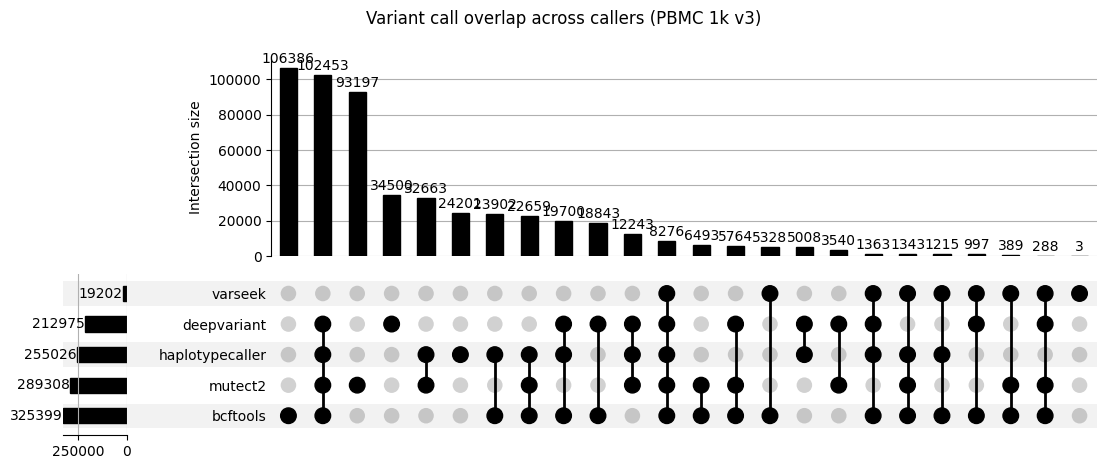

In [31]:
try:
    import upsetplot
except ImportError:
    print("upsetplot not found, installing...")
    !pip install -U -q upsetplot
    import upsetplot

import gzip
import matplotlib.pyplot as plt
from upsetplot import from_contents, UpSet


def read_variant_set(vcf_path):
    """Read a (optionally gzipped) VCF into a set of (CHROM, POS, REF, ALT) keys.
    Multiallelic ALTs are split so each allele is counted separately."""
    if not vcf_path or not os.path.exists(vcf_path):
        return None
    open_func = gzip.open if vcf_path.endswith(".gz") else open
    keys = set()
    with open_func(vcf_path, "rt") as f:
        for line in f:
            if line.startswith("#") or not line.strip():
                continue
            cols = line.rstrip("\n").split("\t")
            if len(cols) < 5:
                continue
            chrom, pos, _id, ref, alt = cols[:5]
            for a in alt.split(","):
                keys.add((chrom, pos, ref, a))
    return keys


# Use the normalized (left-aligned, multiallelic-split) VCFs so all four callers
# share a common coordinate representation. varseek is a variant-sites-only set;
# the GATK/DeepVariant callers are filtered to non-reference calls (_nonref) before
# normalization inside compare_with_happy().
caller_vcfs = {
    "varseek": add_normalized_before_first_dot(vk_count_variants_vcf),
    "deepvariant": add_normalized_before_first_dot(insert_suffix_before_first_dot(deepvariant_vcf, "_nonref")),
    "haplotypecaller": add_normalized_before_first_dot(insert_suffix_before_first_dot(haplotypecaller_vcf, "_nonref")),
    "mutect2": add_normalized_before_first_dot(insert_suffix_before_first_dot(mutect2_vcf, "_nonref")),
    "bcftools": add_normalized_before_first_dot(insert_suffix_before_first_dot(variants_vcf, "_nonref"))
}

caller_sets = {}
for name, path in caller_vcfs.items():
    s = read_variant_set(path)
    if s is None:
        print(f"WARNING: normalized VCF for {name} not found at {path}; excluding from upset plot.")
        continue
    caller_sets[name] = s
    print(f"{name}: {len(s):,} variants ({path})")

if len(caller_sets) >= 2:
    upset_data = from_contents(caller_sets)
    fig = plt.figure(figsize=(11, 6))
    UpSet(upset_data, subset_size="count", show_counts=True, sort_by="cardinality").plot(fig=fig)
    fig.suptitle("Variant call overlap across callers (PBMC 1k v3)")

    upset_png = os.path.join(happy_out, "upset_callers.png")
    os.makedirs(happy_out, exist_ok=True)
    fig.savefig(upset_png, dpi=150, bbox_inches="tight")
    print(f"Saved upset plot to {upset_png}")
    plt.show()
else:
    print("Need at least two caller sets to build an upset plot.")